## Examples: Homogeneous ensemble methods

#### In this train, we'll learn about homogeneous ensemble methods, employing identical models but varying data or parameters to boost diversity and performance.

### Learning Objectives
#### By the end of this train, you should be able to:
##### - Understand homogeneous ensemble methods and their setup.
##### - Discover methods to foster diversity in similar model ensembles.
##### - Assess how these methods affect model precision and robustness

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv('https://github.com/Explore-AI/Public-Data/blob/master/house_price_by_area.csv?raw=true')
df.head()

,LotArea,SalePrice
0,138,1204000
1,145,1274000
2,152,1673000
3,152,1232000
4,152,1195600


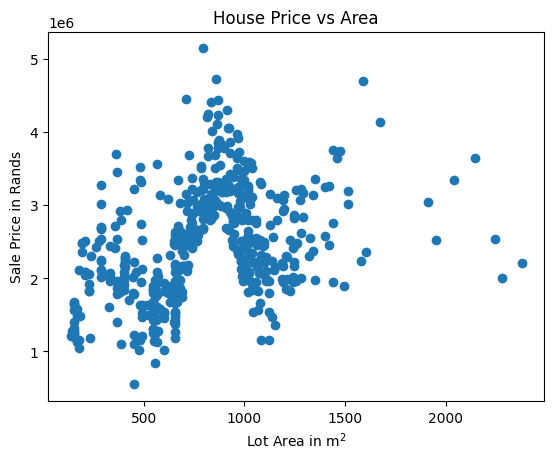

In [5]:
X = df['LotArea']
y = df['SalePrice']

plt.scatter(X,y)
plt.title('House Price vs Area')
plt.xlabel('Lot Area in m$^2$')
plt.ylabel('Sale Price in Rands')
plt.show()

#### Preprocessing

In [18]:
# initialise the scalers
X_scaler = StandardScaler()
y_scaler = StandardScaler()

# Normalise X and y
X_scaled = X_scaler.fit_transform(np.array(X)[:, np.newaxis])
y_scaled = y_scaler.fit_transform(np.array(y)[:, np.newaxis])

# Set test size to 20% of training data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=6)

### a) Bagging (AKA bootstrap aggregating)

In [19]:
# importing the BaggingRegressor class from sklearn
from sklearn.ensemble import BaggingRegressor

#### Building the bagging ensemble

In [53]:
# Instantiate decision tree regression model to use as the base model
d_tree = DecisionTreeRegressor(max_depth=4)

# Instantiate BaggingRegressor model with a decision tree as the base model
bag_reg = BaggingRegressor(base_estimator=d_tree)

In [21]:
import sklearn

In [22]:
print(sklearn.__version__)

1.0.2


#### Training the bagging ensemble

In [54]:
bag_reg.fit(X_train, y_train[:,0])

BaggingRegressor(base_estimator=DecisionTreeRegressor(max_depth=4))

#### Checking the performance of the bagging ensemble

RMSE:  0.7869513673485017


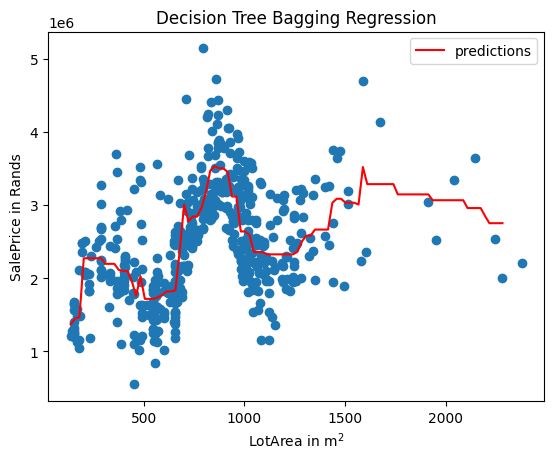

In [55]:
y_pred = bag_reg.predict(X_test)
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot the bagging regression prediction line over data
X_domain = np.linspace(min(X_train), max(X_train), 100)

y_pred_rescaled = y_scaler.inverse_transform(
    bag_reg.predict(X_domain).reshape(-1, 1)
)
X_rescaled = X_scaler.inverse_transform(X_domain)

plt.figure()
plt.scatter(X,y)
plt.plot(X_rescaled, y_pred_rescaled, color='red', label='predictions')
plt.xlabel('LotArea in m$^2$')
plt.ylabel('SalePrice in Rands')
plt.title('Decision Tree Bagging Regression')
plt.legend()
plt.show()

### b) Boosting

In [56]:
# importing the AdaBoostRegressor class from sklearn
from sklearn.ensemble import AdaBoostRegressor

#### Building the boosting ensemble

In [57]:
# Instantiate decision tree regression model to use as the base model
d_tree = DecisionTreeRegressor(max_depth=3)

# Instantiate AdaBoostRegressor model with a decision tree as the base model
bst_reg = AdaBoostRegressor(base_estimator=d_tree)

#### Training the boosting ensemble

In [58]:
bst_reg.fit(X_train, y_train[:,0])

AdaBoostRegressor(base_estimator=DecisionTreeRegressor(max_depth=3))

#### Checking the performance of the boosting ensemble

RMSE:  0.7907754027860006


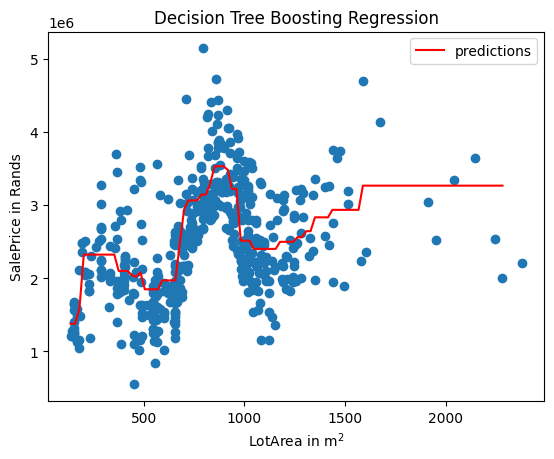

In [59]:
y_pred = bst_reg.predict(X_test)
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot the boosting regression prediction line over data
X_domain_2 = np.linspace(min(X_train), max(X_train), 100)

y_pred_rescaled_2 = y_scaler.inverse_transform(bst_reg.predict(X_domain_2).reshape(-1, 1))
X_rescaled_2 = X_scaler.inverse_transform(X_domain_2)

plt.figure()
plt.scatter(X, y)
plt.plot(X_rescaled_2, y_pred_rescaled_2, color='red', label='predictions')
plt.xlabel('LotArea in m$^2$')
plt.ylabel('SalePrice in Rands')
plt.title('Decision Tree Boosting Regression')
plt.legend()
plt.show()